In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import random

DATASET_PATH = r"Novi Dataset\patches_8000_random"
MODEL_SAVE_PATH = "SavedModels"
MODEL_NAME = "PatchesRandom8000_PointNet.pth"
EPOCHS = 100
PATIENCE = 10
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
BATCH_SIZE = 4

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Training PointNet on RANDOM PATCHES on: {DEVICE}")
print(f"Dataset: {DATASET_PATH} | Seed: {SEED}")

Training PointNet on RANDOM PATCHES on: cuda
Dataset: Novi Dataset\patches_8000_random | Seed: 42


In [2]:
class PatchDataset(Dataset):
    def __init__(self, file_paths, augment=False):
        self.file_paths = file_paths
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        data = np.load(file_path, allow_pickle=True).item()

        points = data['points'].astype(np.float32)
        colors = data['colors'].astype(np.float32)
        labels = data['labels'].astype(np.int64)

        if colors.max() > 1.0:
            colors = colors / 255.0

        if self.augment:
            angle = np.random.uniform(0, 2 * np.pi)
            cos_a, sin_a = np.cos(angle), np.sin(angle)
            rot = np.array([[cos_a, -sin_a, 0],
                            [sin_a,  cos_a, 0],
                            [0,      0,     1]], dtype=np.float32)
            points = points @ rot.T
            points += np.random.randn(*points.shape).astype(np.float32) * 0.005

        features = np.concatenate([points, colors], axis=1)

        return (
            torch.tensor(features, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long),
            file_path
        )

In [3]:
class TNet(nn.Module):
    def __init__(self, k=3):
        super().__init__()
        self.k = k
        self.conv1 = nn.Sequential(nn.Conv1d(k, 64, 1),    nn.BatchNorm1d(64),   nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1),  nn.BatchNorm1d(128),  nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1),nn.BatchNorm1d(1024), nn.ReLU())
        self.fc1   = nn.Sequential(nn.Linear(1024, 512),   nn.BatchNorm1d(512),  nn.ReLU())
        self.fc2   = nn.Sequential(nn.Linear(512, 256),    nn.BatchNorm1d(256),  nn.ReLU())
        self.fc3   = nn.Linear(256, k * k)

        nn.init.zeros_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)
        with torch.no_grad():
            self.fc3.bias.copy_(torch.eye(k).flatten())

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.max(dim=-1)[0]
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x.view(-1, self.k, self.k)


class PointNetRGBSegmentation(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.num_classes = num_classes

        self.tnet3  = TNet(k=3)
        self.conv1  = nn.Sequential(nn.Conv1d(6, 64, 1),    nn.BatchNorm1d(64),   nn.ReLU())
        self.conv2  = nn.Sequential(nn.Conv1d(64, 64, 1),   nn.BatchNorm1d(64),   nn.ReLU())
        self.tnet64 = TNet(k=64)
        self.conv3  = nn.Sequential(nn.Conv1d(64, 64, 1),   nn.BatchNorm1d(64),   nn.ReLU())
        self.conv4  = nn.Sequential(nn.Conv1d(64, 128, 1),  nn.BatchNorm1d(128),  nn.ReLU())
        self.conv5  = nn.Sequential(nn.Conv1d(128, 1024, 1),nn.BatchNorm1d(1024), nn.ReLU())

        self.seg_conv1 = nn.Sequential(nn.Conv1d(1024 + 64, 512, 1), nn.BatchNorm1d(512), nn.ReLU())
        self.seg_conv2 = nn.Sequential(nn.Conv1d(512, 256, 1),       nn.BatchNorm1d(256), nn.ReLU())
        self.seg_conv3 = nn.Sequential(nn.Conv1d(256, 128, 1),       nn.BatchNorm1d(128), nn.ReLU())
        self.seg_conv4 = nn.Sequential(nn.Conv1d(128, 64, 1),        nn.BatchNorm1d(64),  nn.ReLU())
        self.drop      = nn.Dropout(0.5)
        self.seg_conv5 = nn.Conv1d(64, num_classes, 1)

    def forward(self, xyzrgb):
        B, N, _ = xyzrgb.shape

        xyz = xyzrgb[:, :, :3].permute(0, 2, 1)
        x   = xyzrgb.permute(0, 2, 1)

        t3    = self.tnet3(xyz)
        xyz_t = torch.bmm(t3, xyz)
        x     = torch.cat([xyz_t, x[:, 3:, :]], dim=1)

        x = self.conv1(x)
        x = self.conv2(x)

        t64 = self.tnet64(x)
        x   = torch.bmm(t64, x)
        local_feat = x

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        global_feat = x.max(dim=-1)[0].unsqueeze(-1).expand(B, 1024, N)
        x = torch.cat([global_feat, local_feat], dim=1)

        x = self.seg_conv1(x)
        x = self.seg_conv2(x)
        x = self.seg_conv3(x)
        x = self.seg_conv4(x)
        x = self.drop(x)
        x = self.seg_conv5(x)
        return x

In [4]:
patch_pattern = os.path.join(DATASET_PATH, "tree_*", "*", "*.npy")
all_patch_files = glob.glob(patch_pattern)
print(f"Ukupno patcheva: {len(all_patch_files)}")

def get_tree_name(fp):
    return fp.split(os.sep)[-3]

unique_trees = sorted(list(set(get_tree_name(f) for f in all_patch_files)))
print(f"Ukupno stabala: {len(unique_trees)}")

train_trees, test_trees = train_test_split(unique_trees, test_size=0.15, random_state=42)
train_trees, val_trees  = train_test_split(train_trees,  test_size=0.18, random_state=42)
train_trees, val_trees, test_trees = set(train_trees), set(val_trees), set(test_trees)

train_paths = [f for f in all_patch_files if get_tree_name(f) in train_trees]
val_paths   = [f for f in all_patch_files if get_tree_name(f) in val_trees]
test_paths  = [f for f in all_patch_files if get_tree_name(f) in test_trees]

train_dataset = PatchDataset(train_paths, augment=True)
val_dataset   = PatchDataset(val_paths,   augment=False)
test_dataset  = PatchDataset(test_paths,  augment=False)

generator_treninga = torch.Generator()
generator_treninga.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=generator_treninga)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, num_workers=0)

print(f"Train patcheva: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
print(f"Train stabala: {len(train_trees)} | Val: {len(val_trees)} | Test: {len(test_trees)}")

Ukupno patcheva: 8107
Ukupno stabala: 58
Train patcheva: 5460 | Val: 1491 | Test: 1156
Train stabala: 40 | Val: 9 | Test: 9


Ucestalost klasa: {0: 5401212, 1: 26009071, 2: 5546295, 3: 6723422}
Auto alpha: ['2.022', '0.420', '1.969', '1.624']


Epoch 1/100: 100%|██████████| 1365/1365 [01:56<00:00, 11.76it/s, Loss=0.5079]


Epoch [1/100] -> Loss: 0.4775, Train Acc: 0.5491, Val Acc: 0.5199 | Time: 134.8s
--- Best model saved (Val Acc: 0.5199) ---


Epoch 2/100: 100%|██████████| 1365/1365 [01:55<00:00, 11.85it/s, Loss=0.3518]


Epoch [2/100] -> Loss: 0.4235, Train Acc: 0.6058, Val Acc: 0.6122 | Time: 124.5s
--- Best model saved (Val Acc: 0.6122) ---


...

Epoch [58/100] -> Loss: 0.1605, Train Acc: 0.8810, Val Acc: 0.8449 | Time: 124.7s
--- No improvement: 8/10 ---


Epoch 59/100: 100%|██████████| 1365/1365 [01:54<00:00, 11.88it/s, Loss=0.1052]


Epoch [59/100] -> Loss: 0.1582, Train Acc: 0.8833, Val Acc: 0.8561 | Time: 124.4s
--- No improvement: 9/10 ---


Epoch 60/100: 100%|██████████| 1365/1365 [01:54<00:00, 11.88it/s, Loss=0.2356]


Epoch [60/100] -> Loss: 0.1582, Train Acc: 0.8838, Val Acc: 0.8624 | Time: 124.3s
--- No improvement: 10/10 ---
Early stopping triggered after 60 epochs. Best Val Acc: 0.8731

Ukupno vrijeme treninga: 02:04:34


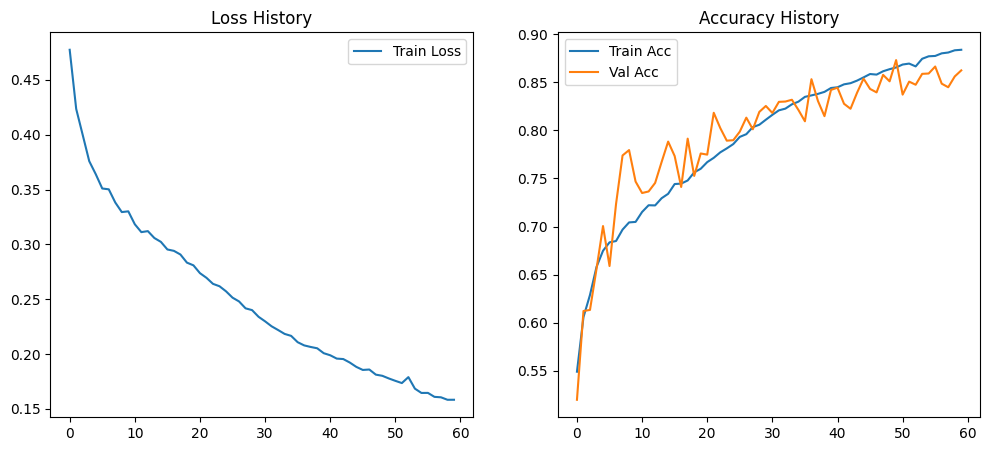

In [5]:
set_seed(SEED)

model = PointNetRGBSegmentation(num_classes=4).to(DEVICE)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([float(alpha)] * NUM_CLASSES)
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float32)
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            at = alpha[targets]
            focal_loss = at * (1 - pt) ** self.gamma * ce_loss
        else:
            focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


def lovasz_grad(gt_sorted):
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1.0 - intersection / union
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    if probas.numel() == 0:
        return probas * 0.0
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()
        if classes == 'present' and fg.sum() == 0:
            continue
        class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    if len(losses) == 0:
        return probas.sum() * 0.0
    return torch.stack(losses).mean()

class LovaszSoftmaxLoss(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, inputs, targets):
        probas = F.softmax(inputs, dim=1)
        B, C, N = probas.shape
        probas = probas.permute(0, 2, 1).reshape(-1, C)
        targets = targets.reshape(-1)
        return lovasz_softmax_flat(probas, targets)


from collections import Counter
brojac = Counter()
for fp in train_paths:
    d = np.load(fp, allow_pickle=True).item()
    lbls = np.array(d['labels'], dtype=np.int64)
    for c in range(NUM_CLASSES):
        brojac[c] += int(np.sum(lbls == c))

ukupno = sum(brojac.values())
alpha_auto = [ukupno / (NUM_CLASSES * brojac[c]) if brojac[c] > 0 else 0.0 for c in range(NUM_CLASSES)]
print("Ucestalost klasa:", dict(brojac))
print("Auto alpha:", [f"{a:.3f}" for a in alpha_auto])

criterion = FocalLoss(alpha=alpha_auto, gamma=2.0)
lovasz = LovaszSoftmaxLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, train_accs, val_accs = [], [], []
best_val_acc = 0.0
patience = PATIENCE
epochs_no_improve = 0

training_start = time.time()

try:
    for epoch in range(EPOCHS):
        epoch_start = time.time()
        model.train()
        epoch_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        for features, labels, _ in pbar:
            features, labels = features.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(features)
            loss = 0.5 * criterion(outputs, labels) + 0.5 * lovasz(outputs, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.numel()

            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for features, labels, _ in val_loader:
                features, labels = features.to(DEVICE), labels.to(DEVICE)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()

        val_acc = val_correct / val_total if val_total > 0 else 0
        val_accs.append(val_acc)

        epoch_time = time.time() - epoch_start
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(MODEL_SAVE_PATH, MODEL_NAME))
            print(f"--- Best model saved (Val Acc: {val_acc:.4f}) ---")
        else:
            epochs_no_improve += 1
            print(f"--- No improvement: {epochs_no_improve}/{patience} ---")
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs. Best Val Acc: {best_val_acc:.4f}")
                break

except KeyboardInterrupt:
    print(f"\nTrening prekinut. Najbolji Val Acc: {best_val_acc:.4f}")

total_time = time.time() - training_start
hours, rem = divmod(total_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"\nUkupno vrijeme treninga: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss History')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.show()

In [6]:
import open3d as o3d
import time
from collections import defaultdict

MODEL_PATH = os.path.join("SavedModels", "PatchesRandom8000_PointNet.pth")

model = PointNetRGBSegmentation(num_classes=4).to(DEVICE)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    print(f"Model loaded from: {MODEL_PATH}")
else:
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}")
model.eval()

KLASE = {0: "deblo", 1: "grane", 2: "potpora", 3: "trava"}


def predict_logits(model, features, device):
    x = torch.tensor(features, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x)
    return out.squeeze(0).permute(1, 0).cpu().numpy()


oblaci = defaultdict(list)
for fp in test_paths:
    tree = fp.split(os.sep)[-3]
    cloud = fp.split(os.sep)[-2]
    oblaci[(tree, cloud)].append(fp)

print(f"Test oblaka: {len(oblaci)}")

conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
oblak_rezultati = []
inference_times = []

for (tree, cloud), patch_files in tqdm(oblaci.items(), desc="Rekonstrukcija po oblaku"):
    p0 = np.load(patch_files[0], allow_pickle=True).item()
    N = int(p0['n_original'])

    logit_sum = np.zeros((N, NUM_CLASSES), dtype=np.float64)
    logit_cnt = np.zeros(N, dtype=np.int64)
    prave_lbl = np.full(N, -1, dtype=np.int64)
    orig_points = np.zeros((N, 3), dtype=np.float64)
    orig_colors = np.zeros((N, 3), dtype=np.float64)

    t0 = time.perf_counter()
    for fp in patch_files:
        p = np.load(fp, allow_pickle=True).item()
        oi = p['orig_idx']
        points = p['points'].astype(np.float32)
        colors = p['colors'].astype(np.float32)
        cols_norm = colors / 255.0 if colors.max() > 1.0 else colors

        features = np.concatenate([points, cols_norm], axis=1)
        logits = predict_logits(model, features, DEVICE)

        logit_sum[oi] += logits
        logit_cnt[oi] += 1
        prave_lbl[oi] = p['labels']
        orig_points[oi] = points
        orig_colors[oi] = cols_norm
    inference_times.append(time.perf_counter() - t0)

    valid = logit_cnt > 0
    logit_avg = logit_sum[valid] / logit_cnt[valid, None]
    pred = np.argmax(logit_avg, axis=1)
    prave = prave_lbl[valid]

    for t, pr in zip(prave, pred):
        conf[t, pr] += 1

    ious = []
    for c in range(NUM_CLASSES):
        tp = np.sum((pred == c) & (prave == c))
        fp_ = np.sum((pred == c) & (prave != c))
        fn = np.sum((pred != c) & (prave == c))
        if np.sum(prave == c) > 0:
            ious.append(tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 1.0)
    miou = np.mean(ious) if ious else 0.0

    oblak_rezultati.append({
        'tree': tree, 'cloud': cloud, 'miou': miou,
        'points': orig_points[valid], 'colors': orig_colors[valid],
        'labels': prave, 'preds': pred,
        'pokriveno': int(valid.sum()), 'ukupno': N
    })

total_points = conf.sum()
accuracy = np.trace(conf) / total_points if total_points > 0 else 0

per_class_iou, per_class_prec, per_class_rec = {}, {}, {}
for c in range(NUM_CLASSES):
    tp = conf[c, c]
    fp_ = conf[:, c].sum() - tp
    fn = conf[c, :].sum() - tp
    per_class_iou[c]  = tp / (tp + fp_ + fn) if (tp + fp_ + fn) > 0 else 0
    per_class_prec[c] = tp / (tp + fp_) if (tp + fp_) > 0 else 0
    per_class_rec[c]  = tp / (tp + fn) if (tp + fn) > 0 else 0
mean_iou = np.mean(list(per_class_iou.values()))

print("\n" + "="*50)
print("FINAL TEST METRICS: RANDOM PATCHES PointNet (rekonstruirano stablo)")
print("="*50)
print(f"Total Points: {total_points:,}")
print(f"Accuracy: {accuracy:.4f}")
print("-"*50)
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10} | IoU: {per_class_iou[c]:.4f} | Prec: {per_class_prec[c]:.4f} | Recall: {per_class_rec[c]:.4f}")
print("-"*50)
print(f"mIoU: {mean_iou:.4f}")
print("="*50)

print("\nConfusion [redak=stvarno, stupac=predvidjeno]:")
print(f"{'':<10}" + "".join(f"{KLASE[c]:<10}" for c in range(NUM_CLASSES)))
for c in range(NUM_CLASSES):
    print(f"{KLASE[c]:<10}" + "".join(f"{conf[c, p]:<10}" for p in range(NUM_CLASSES)))

svi_pokriveni = all(r['pokriveno'] == r['ukupno'] for r in oblak_rezultati)
print(f"\nRekonstrukcija egzaktna (sve tocke pokrivene)? {'DA' if svi_pokriveni else 'NE'}")
avg_inf = np.mean(inference_times)
print(f"Prosjecno vrijeme po stablu: {avg_inf:.3f}s")
print("="*50)

PALETTE = {0: [0.0, 0.0, 1.0], 1: [0.0, 0.8, 0.0], 2: [1.0, 0.0, 0.0], 3: [0.6, 0.6, 0.6]}

def boji_po_klasi(labels):
    c = np.zeros((len(labels), 3))
    for k, col in PALETTE.items():
        c[labels == k] = col
    return c

oblak_rezultati.sort(key=lambda x: x['miou'])
worst = oblak_rezultati[0]
best  = oblak_rezultati[-1]

for tag, rez in [("WORST", worst), ("BEST", best)]:
    print(f"\n[{tag}] {rez['tree']}/{rez['cloud']} | mIoU: {rez['miou']:.4f}")
    pts = rez['points']
    for col, naslov in [(rez['colors'], "ORIGINAL RGB"),
                        (boji_po_klasi(rez['labels']), "LABELE"),
                        (boji_po_klasi(rez['preds']), "PREDIKCIJA")]:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.colors = o3d.utility.Vector3dVector(col)
        o3d.visualization.draw_geometries([pcd], window_name=f"{tag} {naslov} | {rez['tree']} | mIoU {rez['miou']:.3f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Model loaded from: SavedModels\PatchesRandom8000_PointNet.pth
Test oblaka: 92


Rekonstrukcija po oblaku: 100%|██████████| 92/92 [00:25<00:00,  3.56it/s]



FINAL TEST METRICS: RANDOM PATCHES PointNet (rekonstruirano stablo)
Total Points: 8,865,711
Accuracy: 0.8744
--------------------------------------------------
deblo      | IoU: 0.4347 | Prec: 0.5663 | Recall: 0.6516
grane      | IoU: 0.8359 | Prec: 0.8993 | Recall: 0.9222
potpora    | IoU: 0.4561 | Prec: 0.8593 | Recall: 0.4929
trava      | IoU: 0.9979 | Prec: 0.9981 | Recall: 0.9999
--------------------------------------------------
mIoU: 0.6812

Confusion [redak=stvarno, stupac=predvidjeno]:
          deblo     grane     potpora   trava     
deblo     600516    304623    15804     673       
grane     409536    5321153   38693     685       
potpora   50299     291099    333385    1555      
trava     100       10        85        1497495   

Rekonstrukcija egzaktna (sve tocke pokrivene)? DA
Prosjecno vrijeme po stablu: 0.207s

[WORST] tree_1_V_0000/3 | mIoU: 0.3451

[BEST] tree_1_V_0178/4 | mIoU: 0.9919
